# 🥉 Bronze Layer: Data Ingestion

Trong bước này, chúng ta nạp dữ liệu gốc từ nguồn CSV vào Databricks và lưu dưới dạng Delta table.

Mục tiêu của Bronze layer là:
- Lưu dữ liệu ở trạng thái gần với nguồn nhất
- Chưa thực hiện làm sạch dữ liệu
- Chưa xử lý missing values, duplicates hay outliers
- Thêm metadata để phục vụ truy vết nguồn dữ liệu

In [0]:
from pyspark.sql.functions import median, coalesce, when, lit, current_timestamp, to_timestamp, to_date

# Cấu hình Catalog và Schema
spark.sql("USE CATALOG main")
spark.sql("USE SCHEMA netflix")

# Đường dẫn dữ liệu nguồn
source_base_path = "/Volumes/main/netflix/raw/"

##_Reset Flag_

In [0]:
RESET_ALL_TABLES = False   # Set to False after first run

if RESET_ALL_TABLES:
    for tbl in ["users", "movies", "watch_history", "recommendation_logs", "search_logs", "reviews"]:
        spark.sql(f"DROP TABLE IF EXISTS main.netflix.bronze_{tbl}")

## HÀM INGEST DỮ LIỆU VÀO BRONZE (DELTA TABLE)

In [0]:
from pyspark.sql.functions import current_timestamp, lit

spark.sql("USE CATALOG main")
spark.sql("USE SCHEMA netflix")

source_base_path = "/Volumes/main/netflix/raw/"

def ingest_to_bronze(file_name, table_name):
    source_path = source_base_path + file_name
    
    df_raw = spark.read \
        .format("csv") \
        .option("header", True) \
        .option("inferSchema", False) \
        .option("multiLine", True) \
        .option("escape", "\"") \
        .load(source_path)
    
    df_bronze = df_raw \
        .withColumn("_source_file", lit(file_name)) \
        .withColumn("_ingest_time", current_timestamp()) \
        .withColumn("_batch_id", lit("batch_001"))
    
    table_full_name = f"main.netflix.bronze_{table_name}"
    
    # Append – table will be created on first run with the correct schema
    df_bronze.write \
        .format("delta") \
        .mode("append") \
        .saveAsTable(table_full_name)
    
    print(f"✅ Ingested {file_name} -> {table_full_name}")

# Ingest all files (no CREATE/TRUNCATE)
ingest_to_bronze("users.csv", "users")
ingest_to_bronze("movies.csv", "movies")
ingest_to_bronze("watch_history.csv", "watch_history")
ingest_to_bronze("recommendation_logs.csv", "recommendation_logs")
ingest_to_bronze("search_logs.csv", "search_logs")
ingest_to_bronze("reviews.csv", "reviews")

✅ Ingested users.csv -> main.netflix.bronze_users
✅ Ingested movies.csv -> main.netflix.bronze_movies
✅ Ingested watch_history.csv -> main.netflix.bronze_watch_history
✅ Ingested recommendation_logs.csv -> main.netflix.bronze_recommendation_logs
✅ Ingested search_logs.csv -> main.netflix.bronze_search_logs
✅ Ingested reviews.csv -> main.netflix.bronze_reviews


## ✅ Kiểm tra sau khi nạp vào Bronze

Sau khi ingest, chúng ta chỉ kiểm tra nhanh:
- Số dòng dữ liệu
- Schema của bảng
- Một vài bản ghi mẫu

Lưu ý: Ở Bronze layer, chúng ta **chưa xử lý dữ liệu**

In [0]:
def check_bronze_table(table_name):
    """
    Kiểm tra nhanh dữ liệu trong Bronze layer.
    Tham số: table_name (ví dụ: "users")
    """
    table_full_name = f"main.netflix.bronze_{table_name}"
    
    print(f"\n{'='*60}")
    print(f"📊 Đang kiểm tra: {table_full_name}")
    print('='*60)
    
    # 1. Số dòng
    row_count = spark.table(table_full_name).count()
    print(f"✅ Số dòng dữ liệu: {row_count}")
    
    # 2. Schema
    print("\n📐 Schema:")
    spark.table(table_full_name).printSchema()
    
    # 3. Mẫu dữ liệu (5 dòng)
    print("\n🔍 Dữ liệu mẫu (5 dòng):")
    display(spark.table(table_full_name).limit(5))
    
    print("-"*60)

# Kiểm tra lần lượt từng bảng
for tbl in ["users", "movies", "watch_history", "recommendation_logs", "search_logs", "reviews"]:
    check_bronze_table(tbl)


📊 Đang kiểm tra: main.netflix.bronze_users
✅ Số dòng dữ liệu: 20600

📐 Schema:
root
 |-- user_id: string (nullable = true)
 |-- email: string (nullable = true)
 |-- first_name: string (nullable = true)
 |-- last_name: string (nullable = true)
 |-- age: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- country: string (nullable = true)
 |-- state_province: string (nullable = true)
 |-- city: string (nullable = true)
 |-- subscription_plan: string (nullable = true)
 |-- subscription_start_date: string (nullable = true)
 |-- is_active: string (nullable = true)
 |-- monthly_spend: string (nullable = true)
 |-- primary_device: string (nullable = true)
 |-- household_size: string (nullable = true)
 |-- created_at: string (nullable = true)
 |-- _source_file: string (nullable = true)
 |-- _ingest_time: timestamp (nullable = true)
 |-- _batch_id: string (nullable = true)


🔍 Dữ liệu mẫu (5 dòng):


user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,subscription_start_date,is_active,monthly_spend,primary_device,household_size,created_at,_source_file,_ingest_time,_batch_id
user_00001,figueroajohn@example.org,Erica,Garza,43.0,Male,USA,Massachusetts,North Jefferyhaven,Basic,2024-04-08,True,36.06,Laptop,1.0,2023-04-01 14:40:50.540242,users.csv,2026-05-05T11:04:02.885Z,batch_001
user_00002,blakeerik@example.com,Joshua,Bernard,38.0,Male,USA,Texas,North Noahstad,Premium+,2024-05-24,True,14.59,Desktop,2.0,2024-10-10 15:39:11.030515,users.csv,2026-05-05T11:04:02.885Z,batch_001
user_00003,smiller@example.net,Barbara,Williams,32.0,Female,USA,Michigan,Traciebury,Standard,2023-09-22,False,11.71,Desktop,3.0,2024-06-29 14:27:49.560875,users.csv,2026-05-05T11:04:02.885Z,batch_001
user_00004,mitchellclark@example.com,Chelsea,Ferguson,11.0,Male,USA,Ohio,South Noah,Standard,2024-08-21,True,28.56,Laptop,2.0,2023-04-11 01:01:59.614841,users.csv,2026-05-05T11:04:02.885Z,batch_001
user_00005,richard13@example.net,Jason,Foster,21.0,Female,USA,Arizona,West Donald,Standard,2024-10-28,True,9.54,Desktop,6.0,2025-04-12 19:59:30.137806,users.csv,2026-05-05T11:04:02.885Z,batch_001


------------------------------------------------------------

📊 Đang kiểm tra: main.netflix.bronze_movies
✅ Số dòng dữ liệu: 2080

📐 Schema:
root
 |-- movie_id: string (nullable = true)
 |-- title: string (nullable = true)
 |-- content_type: string (nullable = true)
 |-- genre_primary: string (nullable = true)
 |-- genre_secondary: string (nullable = true)
 |-- release_year: string (nullable = true)
 |-- duration_minutes: string (nullable = true)
 |-- rating: string (nullable = true)
 |-- language: string (nullable = true)
 |-- country_of_origin: string (nullable = true)
 |-- imdb_rating: string (nullable = true)
 |-- production_budget: string (nullable = true)
 |-- box_office_revenue: string (nullable = true)
 |-- number_of_seasons: string (nullable = true)
 |-- number_of_episodes: string (nullable = true)
 |-- is_netflix_original: string (nullable = true)
 |-- added_to_platform: string (nullable = true)
 |-- content_warning: string (nullable = true)
 |-- _source_file: string (nullabl

movie_id,title,content_type,genre_primary,genre_secondary,release_year,duration_minutes,rating,language,country_of_origin,imdb_rating,production_budget,box_office_revenue,number_of_seasons,number_of_episodes,is_netflix_original,added_to_platform,content_warning,_source_file,_ingest_time,_batch_id
movie_0001,Dragon Legend,Stand-up Comedy,History,Thriller,2014,35.0,TV-Y,French,Japan,null,null,null,null,null,False,2023-08-07,False,movies.csv,2026-05-05T11:04:09.007Z,batch_001
movie_0002,Storm Warrior,Stand-up Comedy,Sci-Fi,null,2017,37.0,PG,Japanese,USA,3.3,null,null,null,null,False,2022-01-28,True,movies.csv,2026-05-05T11:04:09.007Z,batch_001
movie_0003,Fire Family,Movie,Drama,null,2003,142.0,TV-MA,English,USA,8.5,2114120.0,null,null,null,False,2021-05-04,True,movies.csv,2026-05-05T11:04:09.007Z,batch_001
movie_0004,Our Princess,Documentary,Sci-Fi,null,2011,131.0,NC-17,Japanese,USA,5.3,null,null,null,null,False,2022-11-26,False,movies.csv,2026-05-05T11:04:09.007Z,batch_001
movie_0005,Warrior Mission,Documentary,Sport,Mystery,2015,91.0,TV-G,English,USA,3.1,null,null,null,null,False,2023-06-15,False,movies.csv,2026-05-05T11:04:09.007Z,batch_001


------------------------------------------------------------

📊 Đang kiểm tra: main.netflix.bronze_watch_history
✅ Số dòng dữ liệu: 210000

📐 Schema:
root
 |-- session_id: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- movie_id: string (nullable = true)
 |-- watch_date: string (nullable = true)
 |-- device_type: string (nullable = true)
 |-- watch_duration_minutes: string (nullable = true)
 |-- progress_percentage: string (nullable = true)
 |-- action: string (nullable = true)
 |-- quality: string (nullable = true)
 |-- location_country: string (nullable = true)
 |-- is_download: string (nullable = true)
 |-- user_rating: string (nullable = true)
 |-- _source_file: string (nullable = true)
 |-- _ingest_time: timestamp (nullable = true)
 |-- _batch_id: string (nullable = true)


🔍 Dữ liệu mẫu (5 dòng):


...

------------------------------------------------------------

📊 Đang kiểm tra: main.netflix.bronze_search_logs
✅ Số dòng dữ liệu: 53000

📐 Schema:
root
 |-- search_id: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- search_query: string (nullable = true)
 |-- search_date: string (nullable = true)
 |-- results_returned: string (nullable = true)
 |-- clicked_result_position: string (nullable = true)
 |-- device_type: string (nullable = true)
 |-- search_duration_seconds: string (nullable = true)
 |-- had_typo: string (nullable = true)
 |-- used_filters: string (nullable = true)
 |-- location_country: string (nullable = true)
 |-- _source_file: string (nullable = true)
 |-- _ingest_time: timestamp (nullable = true)
 |-- _batch_id: string (nullable = true)


🔍 Dữ liệu mẫu (5 dòng):


search_id,user_id,search_query,search_date,results_returned,clicked_result_position,device_type,search_duration_seconds,had_typo,used_filters,location_country,_source_file,_ingest_time,_batch_id
search_000001,user_09864,classic movies,2024-03-22,20,2,Tablet,12.4,False,False,Canada,search_logs.csv,2026-05-05T11:04:19.207Z,batch_001
search_000002,user_08038,stand up comedy,2025-11-22,24,4,Tablet,63.5,True,False,USA,search_logs.csv,2026-05-05T11:04:19.207Z,batch_001
search_000003,user_02009,music documentaries,2024-10-09,86,1,Tablet,24.7,True,False,USA,search_logs.csv,2026-05-05T11:04:19.207Z,batch_001
search_000004,user_01083,comedy shows,2024-12-14,70,4,Mobile,53.7,False,False,USA,search_logs.csv,2026-05-05T11:04:19.207Z,batch_001
search_000005,user_04269,movies based on true stories,2025-01-10,48,null,Tablet,69.6,True,False,USA,search_logs.csv,2026-05-05T11:04:19.207Z,batch_001


------------------------------------------------------------

📊 Đang kiểm tra: main.netflix.bronze_reviews
✅ Số dòng dữ liệu: 30900

📐 Schema:
root
 |-- review_id: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- movie_id: string (nullable = true)
 |-- rating: string (nullable = true)
 |-- review_date: string (nullable = true)
 |-- device_type: string (nullable = true)
 |-- is_verified_watch: string (nullable = true)
 |-- helpful_votes: string (nullable = true)
 |-- total_votes: string (nullable = true)
 |-- review_text: string (nullable = true)
 |-- sentiment: string (nullable = true)
 |-- sentiment_score: string (nullable = true)
 |-- _source_file: string (nullable = true)
 |-- _ingest_time: timestamp (nullable = true)
 |-- _batch_id: string (nullable = true)


🔍 Dữ liệu mẫu (5 dòng):


review_id,user_id,movie_id,rating,review_date,device_type,is_verified_watch,helpful_votes,total_votes,review_text,sentiment,sentiment_score,_source_file,_ingest_time,_batch_id
review_000001,user_07066,movie_0360,4,2025-03-29,Mobile,False,3.0,5.0,Fantastic cinematography and plot twists.,positive,0.711,reviews.csv,2026-05-05T09:27:37.030Z,batch_001
review_000002,user_02953,movie_0095,5,2024-07-19,Mobile,True,2.0,2.0,This series is a masterpiece!,positive,0.645,reviews.csv,2026-05-05T09:27:37.030Z,batch_001
review_000003,user_05528,movie_0518,4,2025-02-11,Tablet,True,2.0,5.0,Fantastic cinematography and plot twists.,positive,0.73,reviews.csv,2026-05-05T09:27:37.030Z,batch_001
review_000004,user_07612,movie_0672,5,2025-11-26,Mobile,True,7.0,7.0,One of the best series I've ever watched. Highly recommend!,positive,0.798,reviews.csv,2026-05-05T09:27:37.030Z,batch_001
review_000005,user_03424,movie_0580,3,2025-07-11,Mobile,True,1.0,5.0,Mixed feelings about this one.,neutral,0.41,reviews.csv,2026-05-05T09:27:37.030Z,batch_001


------------------------------------------------------------


# Silver Layer: Data Cleaning

- Đọc dữ liệu thô từ Bronze (đã có _ingest_time, _source_file, _batch_id).

- Chỉ xử lý những bản ghi mới chưa từng được làm sạch (dựa vào watermark).

- Áp dụng các bước:

  - Chuyển đổi kiểu dữ liệu (string → int, float, date, boolean).

  - Xử lý giá trị thiếu (missing) bằng median hoặc 'Unknown'.

  - Xử lý outlier bằng phương pháp Winsorization (capping theo percentile 5% và 95%).

  - Loại bỏ trùng lặp dựa trên khóa chính.

  - Ghi kết quả vào bảng Silver bằng MERGE (upsert) để hỗ trợ incremental.

## Cấu hình và Reset Flag

In [0]:
# Cấu hình Silver layer
RESET_SILVER = False   # Chuyển thành False sau khi đã chạy lần đầu (production sẽ luôn False)

# Nếu reset, xóa toàn bộ bảng Silver cũ
if RESET_SILVER:
    for tbl in ["users", "watch_history", "reviews", "movies"]:
        spark.sql(f"DROP TABLE IF EXISTS main.netflix.silver_{tbl}")
    print("✅ Đã reset các bảng Silver (xóa cũ).")
else:
    print("🟡 Chạy ở chế độ incremental (không reset).")

🟡 Chạy ở chế độ incremental (không reset).


## Lập các hàm helper
- "_winsorize_column_": Hàm này tính percentile 5% và 95% trên toàn bộ DataFrame (hoặc trên batch đang xử lý), sau đó thay thế các giá trị dưới 5% bằng giá trị percentile 5%, trên 95% bằng percentile 95%. Kết quả trả về cột mới _capped và các ngưỡng để có thể log.

- "_merge_to_silver_": Thực hiện MERGE (upsert) từ DataFrame mới vào bảng Silver hiện có. Nếu bảng chưa tồn tại, tự động tạo mới bằng overwrite.

- "_get_last_processed_time_": Trả về timestamp lớn nhất của cột _cleaned_timestamp trong bảng Silver. Nếu bảng chưa tồn tại, trả về '1900-01-01 00:00:00' để xử lý toàn bộ.

In [0]:
from pyspark.sql import DataFrame
from pyspark.sql.functions import col, when, percentile_approx, current_timestamp, lit
from pyspark.sql.types import IntegerType, FloatType, BooleanType
from delta.tables import DeltaTable

# 1. Winsorization (capping outliers theo percentile)
def winsorize_column(df: DataFrame, col_name: str, 
                     lower_percentile: float = 0.05, 
                     upper_percentile: float = 0.95):
    bounds = df.select(
        percentile_approx(col_name, lower_percentile).alias("lower"),
        percentile_approx(col_name, upper_percentile).alias("upper")
    ).collect()[0]
    lower = bounds["lower"]
    upper = bounds["upper"]
    
    df_capped = df.withColumn(
        f"{col_name}_capped",
        when(col(col_name) < lower, lower)
        .when(col(col_name) > upper, upper)
        .otherwise(col(col_name))
    )
    return df_capped, lower, upper

# 2. Upsert (MERGE) vào bảng Silver
def merge_to_silver(df_updates: DataFrame, silver_table: str, merge_keys: list):
    table_full = f"main.netflix.{silver_table}"
    
    if spark.catalog.tableExists(table_full):
        delta_table = DeltaTable.forName(spark, table_full)
        merge_condition = " AND ".join([f"target.{k} = source.{k}" for k in merge_keys])
        row_count = df_updates.count()
        delta_table.alias("target") \
            .merge(df_updates.alias("source"), merge_condition) \
            .whenMatchedUpdateAll() \
            .whenNotMatchedInsertAll() \
            .execute()
        print(f"✅ Merged {row_count} rows into {silver_table}")
    else:
        df_updates.write.format("delta").mode("overwrite").saveAsTable(table_full)
        print(f"✅ Created new table {silver_table} with {df_updates.count()} rows")

# 3. Lấy watermark (lần xử lý cuối cùng) từ bảng Silver
def get_last_processed_time(silver_table: str) -> str:
    table_full = f"main.netflix.{silver_table}"
    if spark.catalog.tableExists(table_full):
        last_time = spark.sql(f"SELECT MAX(_cleaned_timestamp) as max_time FROM {table_full}").collect()[0][0]
        return last_time if last_time is not None else "1900-01-01 00:00:00"
    else:
        return "1900-01-01 00:00:00"

## Clean bảng users

1. Loại bỏ trùng lặp theo `user_id` (khóa chính), giữ bản ghi có `_ingest_time` mới nhất.

2. Chuyển đổi kiểu:
   - `age` → Integer (float trong raw, ép về int).
   - `monthly_spend` → Float.
   - `household_size` → Integer.
   - `subscription_start_date` → Date (định dạng 'yyyy-MM-dd').
   - `created_at` → Timestamp.
   - `is_active` → Boolean (từ string 'Yes'/'No' hoặc True/False).

3. Xử lý missing:
   - `age`, `monthly_spend`, `household_size`: điền bằng median của batch hiện tại.
   - `gender`, `primary_device`, `country`: thay bằng 'Unknown'.
   - `state_province`, `city`: thay bằng 'Unknown'.

4. Winsorize (cắt outlier):
   - `age`: cắt ở percentile 5% và 95% (khoảng tuổi bất thường 5-110).
   - `monthly_spend`: cắt tương tự (giá trị cực cao $200-1000).
   - `household_size`: cắt outlier (0 hoặc >20).

5. Thêm metadata `_cleaned_timestamp`, `_data_version = 'v1'`.

6. Trả về DataFrame với các cột đã được làm sạch (giữ tên cột gốc).

In [0]:
def clean_users(df_new: DataFrame) -> DataFrame:
    """
    Làm sạch bảng users – xử lý age, monthly_spend, household_size.
    """
    # 1. Loại bỏ duplicate user_id (giữ bản ghi có _ingest_time lớn nhất)
    df_dedup = df_new.dropDuplicates(["user_id"]).orderBy(col("_ingest_time").desc())
    
    # 2. Chuyển đổi kiểu an toàn:
    df_typed = df_dedup \
        .withColumn("age_double", col("age").cast("double")) \
        .withColumn("monthly_spend_double", col("monthly_spend").cast("double")) \
        .withColumn("household_size_double", col("household_size").cast("double")) \
        .withColumn("subscription_start_date", to_date(col("subscription_start_date"), "yyyy-MM-dd")) \
        .withColumn("created_at", to_timestamp(col("created_at"))) \
        .withColumn("is_active_bool", 
                    when(col("is_active") == "Yes", True)
                    .when(col("is_active") == "True", True)
                    .otherwise(False))
    
    # 3. Tính median (dùng double)
    med_age = df_typed.select(median("age_double")).collect()[0][0] or 30.0
    med_spend = df_typed.select(median("monthly_spend_double")).collect()[0][0] or 15.0
    med_household = df_typed.select(median("household_size_double")).collect()[0][0] or 2.0
    
    # 4. Điền missing
    df_filled = df_typed \
        .withColumn("age_filled_double", coalesce(col("age_double"), lit(med_age))) \
        .withColumn("monthly_spend_filled", coalesce(col("monthly_spend_double"), lit(med_spend))) \
        .withColumn("household_size_filled_double", coalesce(col("household_size_double"), lit(med_household))) \
        .withColumn("gender_filled", when(col("gender").isNull(), "Unknown").otherwise(col("gender"))) \
        .withColumn("country_filled", when(col("country").isNull(), "Unknown").otherwise(col("country"))) \
        .withColumn("primary_device_filled", when(col("primary_device").isNull(), "Unknown").otherwise(col("primary_device"))) \
        .withColumn("state_province_filled", when(col("state_province").isNull(), "Unknown").otherwise(col("state_province"))) \
        .withColumn("city_filled", when(col("city").isNull(), "Unknown").otherwise(col("city")))
    
    # 5. Winsorization (capping outlier)
    age_capped_df, _, _ = winsorize_column(df_filled, "age_filled_double")
    spend_capped_df, _, _ = winsorize_column(age_capped_df, "monthly_spend_filled")
    household_capped_df, _, _ = winsorize_column(spend_capped_df, "household_size_filled_double")
    
    # 6. Chọn cột cuối, ép về int cho age và household_size
    df_silver = household_capped_df.select(
        col("user_id"),
        col("email"),
        col("first_name"),
        col("last_name"),
        col("age_filled_double_capped").cast("int").alias("age"),
        col("gender_filled").alias("gender"),
        col("country_filled").alias("country"),
        col("state_province_filled").alias("state_province"),
        col("city_filled").alias("city"),
        col("subscription_plan"),
        col("subscription_start_date"),
        col("is_active_bool").alias("is_active"),
        col("monthly_spend_filled_capped").alias("monthly_spend"),
        col("primary_device_filled").alias("primary_device"),
        col("household_size_filled_double_capped").cast("int").alias("household_size"),
        col("created_at"),
        # Metadata
        lit(current_timestamp()).alias("_cleaned_timestamp"),
        lit("v1").alias("_data_version"),
        col("_source_file"),
        col("_ingest_time"),
        col("_batch_id")
    )
    
    return df_silver

## Clean bảng watch_history

1. Loại bỏ trùng lặp theo `session_id` (khóa chính).

2. Chuyển đổi kiểu:
   - `watch_date` → Timestamp.
   - `watch_duration_minutes` → Float (missing 8%).
   - `progress_percentage` → Float (missing 12%).
   - `is_download` → Boolean (từ string 'True'/'False' hoặc 0/1).
   - `user_rating` → Float (missing 85% – giữ nguyên null).

3. Xử lý missing:
   - `watch_duration_minutes`: điền bằng median (giả sử 30 phút).
   - `progress_percentage`: điền bằng median (có thể là 0 hoặc 50).
   - `quality`: thay bằng 'Unknown'.
   - `device_type`: nếu missing → 'Unknown'.
   - `location_country`: thay bằng 'Unknown'.
   - `action`: giữ nguyên vì ít missing.

4. Winsorize:
   - `watch_duration_minutes`: cắt ở percentile 5% và 95% (binge-watching outlier có thể > 5 giờ).
   - `progress_percentage`: cắt ở [0,100] nhưng percentile đã đảm bảo nằm trong khoảng.

5. Thêm metadata `_cleaned_timestamp`, `_data_version`.

6. Trả về DataFrame với tất cả cột gốc + cột đã được làm sạch.

In [0]:
def clean_watch_history(df_new: DataFrame) -> DataFrame:
    df_dedup = df_new.dropDuplicates(["session_id"])
    
    df_typed = df_dedup \
        .withColumn("watch_date_ts", to_timestamp(col("watch_date"))) \
        .withColumn("watch_duration_min", col("watch_duration_minutes").cast("double")) \
        .withColumn("progress_pct", col("progress_percentage").cast("double")) \
        .withColumn("is_download_bool", when(col("is_download") == "True", True).otherwise(False)) \
        .withColumn("user_rating_float", col("user_rating").cast("double"))
    
    med_duration = df_typed.select(median("watch_duration_min")).collect()[0][0] or 30.0
    med_progress = df_typed.select(median("progress_pct")).collect()[0][0] or 80.0
    
    df_filled = df_typed \
        .withColumn("watch_duration_filled", coalesce(col("watch_duration_min"), lit(med_duration))) \
        .withColumn("progress_filled", coalesce(col("progress_pct"), lit(med_progress))) \
        .withColumn("quality_filled", when(col("quality").isNull(), "Unknown").otherwise(col("quality"))) \
        .withColumn("device_type_filled", when(col("device_type").isNull(), "Unknown").otherwise(col("device_type"))) \
        .withColumn("location_country_filled", when(col("location_country").isNull(), "Unknown").otherwise(col("location_country")))
    
    duration_capped, _, _ = winsorize_column(df_filled, "watch_duration_filled")
    progress_capped, _, _ = winsorize_column(duration_capped, "progress_filled")
    
    df_silver = progress_capped.select(
        col("session_id"),
        col("user_id"),
        col("movie_id"),
        col("watch_date_ts").alias("watch_date"),
        col("device_type_filled").alias("device_type"),
        col("watch_duration_filled_capped").alias("watch_duration_minutes"),
        col("progress_filled_capped").alias("progress_percentage"),
        col("action"),
        col("quality_filled").alias("quality"),
        col("location_country_filled").alias("location_country"),
        col("is_download_bool").alias("is_download"),
        col("user_rating_float").alias("user_rating"),
        lit(current_timestamp()).alias("_cleaned_timestamp"),
        lit("v1").alias("_data_version"),
        col("_source_file"), col("_ingest_time"), col("_batch_id")
    )
    return df_silver

## Clean bảng movies

1. Loại bỏ trùng lặp theo `movie_id` (khóa chính).

2. Chuyển đổi kiểu:
   - `release_year` → Integer.
   - `duration_minutes` → Float.
   - `imdb_rating` → Float.
   - `production_budget`, `box_office_revenue` → Float.
   - `number_of_seasons`, `number_of_episodes` → Integer.
   - `is_netflix_original`, `content_warning` → Boolean.
   - `added_to_platform` → Date.

3. Xử lý missing:
   - `release_year`, `duration_minutes`, `imdb_rating`, `production_budget`, `box_office_revenue`, `number_of_seasons`, `number_of_episodes`: điền bằng median.
   - `genre_secondary`, `rating`, `language`, `country_of_origin`, `content_type`, `genre_primary`: thay bằng 'Unknown'.

4. Winsorize:
   - `duration_minutes`, `imdb_rating`, `production_budget`, `box_office_revenue`: cắt ở percentile 5% và 95%.

5. Thêm metadata `_cleaned_timestamp`, `_data_version`.

6. Trả về DataFrame với các cột đã làm sạch.

In [0]:
def clean_movies(df_new: DataFrame) -> DataFrame:
    df_dedup = df_new.dropDuplicates(["movie_id"])
    
    # Chuyển đổi kiểu: số thực từ string -> double, sau đó mới cast sang int nếu cần
    df_typed = df_dedup \
        .withColumn("release_year_double", col("release_year").cast("double")) \
        .withColumn("release_year_int", col("release_year_double").cast("int")) \
        .withColumn("duration_min_float", col("duration_minutes").cast("double")) \
        .withColumn("imdb_rating_float", col("imdb_rating").cast("double")) \
        .withColumn("production_budget_float", col("production_budget").cast("double")) \
        .withColumn("box_office_revenue_float", col("box_office_revenue").cast("double")) \
        .withColumn("number_of_seasons_double", col("number_of_seasons").cast("double")) \
        .withColumn("number_of_seasons_int", col("number_of_seasons_double").cast("int")) \
        .withColumn("number_of_episodes_double", col("number_of_episodes").cast("double")) \
        .withColumn("number_of_episodes_int", col("number_of_episodes_double").cast("int")) \
        .withColumn("is_netflix_original_bool", when(col("is_netflix_original") == "Yes", True).otherwise(False)) \
        .withColumn("content_warning_bool", when(col("content_warning") == "Yes", True).otherwise(False)) \
        .withColumn("added_to_platform_date", to_date(col("added_to_platform"), "yyyy-MM-dd"))
    
    # Median (dùng double để an toàn)
    med_year = df_typed.select(median("release_year_double")).collect()[0][0] or 2020.0
    med_duration = df_typed.select(median("duration_min_float")).collect()[0][0] or 90.0
    med_imdb = df_typed.select(median("imdb_rating_float")).collect()[0][0] or 6.5
    med_budget = df_typed.select(median("production_budget_float")).collect()[0][0] or 50000000.0
    med_revenue = df_typed.select(median("box_office_revenue_float")).collect()[0][0] or 100000000.0
    med_seasons = df_typed.select(median("number_of_seasons_double")).collect()[0][0] or 1.0
    med_episodes = df_typed.select(median("number_of_episodes_double")).collect()[0][0] or 10.0
    
    df_filled = df_typed \
        .withColumn("release_year_filled", coalesce(col("release_year_double"), lit(med_year))) \
        .withColumn("duration_filled", coalesce(col("duration_min_float"), lit(med_duration))) \
        .withColumn("imdb_rating_filled", coalesce(col("imdb_rating_float"), lit(med_imdb))) \
        .withColumn("production_budget_filled", coalesce(col("production_budget_float"), lit(med_budget))) \
        .withColumn("box_office_revenue_filled", coalesce(col("box_office_revenue_float"), lit(med_revenue))) \
        .withColumn("number_of_seasons_filled_double", coalesce(col("number_of_seasons_double"), lit(med_seasons))) \
        .withColumn("number_of_seasons_filled", col("number_of_seasons_filled_double").cast("int")) \
        .withColumn("number_of_episodes_filled_double", coalesce(col("number_of_episodes_double"), lit(med_episodes))) \
        .withColumn("number_of_episodes_filled", col("number_of_episodes_filled_double").cast("int")) \
        .withColumn("genre_secondary_filled", when(col("genre_secondary").isNull(), "Unknown").otherwise(col("genre_secondary"))) \
        .withColumn("rating_filled", when(col("rating").isNull(), "Unknown").otherwise(col("rating"))) \
        .withColumn("language_filled", when(col("language").isNull(), "Unknown").otherwise(col("language"))) \
        .withColumn("country_of_origin_filled", when(col("country_of_origin").isNull(), "Unknown").otherwise(col("country_of_origin"))) \
        .withColumn("content_type_filled", when(col("content_type").isNull(), "Unknown").otherwise(col("content_type"))) \
        .withColumn("genre_primary_filled", when(col("genre_primary").isNull(), "Unknown").otherwise(col("genre_primary")))
    
    # Winsorization
    dur_capped, _, _ = winsorize_column(df_filled, "duration_filled")
    imdb_capped, _, _ = winsorize_column(dur_capped, "imdb_rating_filled")
    budget_capped, _, _ = winsorize_column(imdb_capped, "production_budget_filled")
    revenue_capped, _, _ = winsorize_column(budget_capped, "box_office_revenue_filled")
    
    df_silver = revenue_capped.select(
        col("movie_id"), col("title"),
        col("content_type_filled").alias("content_type"),
        col("genre_primary_filled").alias("genre_primary"),
        col("genre_secondary_filled").alias("genre_secondary"),
        col("release_year_filled").cast("int").alias("release_year"),
        col("duration_filled_capped").alias("duration_minutes"),
        col("rating_filled").alias("rating"),
        col("language_filled").alias("language"),
        col("country_of_origin_filled").alias("country_of_origin"),
        col("imdb_rating_filled_capped").alias("imdb_rating"),
        col("production_budget_filled_capped").alias("production_budget"),
        col("box_office_revenue_filled_capped").alias("box_office_revenue"),
        col("number_of_seasons_filled").alias("number_of_seasons"),
        col("number_of_episodes_filled").alias("number_of_episodes"),
        col("is_netflix_original_bool").alias("is_netflix_original"),
        col("added_to_platform_date").alias("added_to_platform"),
        col("content_warning_bool").alias("content_warning"),
        lit(current_timestamp()).alias("_cleaned_timestamp"),
        lit("v1").alias("_data_version"),
        col("_source_file"), col("_ingest_time"), col("_batch_id")
    )
    return df_silver

## Clean bảng reviews

1. Loại bỏ trùng lặp theo tổ hợp `(user_id, movie_id, review_date)` (khóa chính).

2. Chuyển đổi kiểu:
   - `rating` → Float.
   - `review_date` → Date.

3. Xử lý missing:
   - `rating`: điền bằng median (giá trị 1-5, mặc định 3.0).
   - `sentiment`: thay bằng 'neutral'.
   - `review_text`: thay bằng chuỗi rỗng.

4. Xử lý outlier:
   - `rating`: nếu < 1 → đặt thành 1, nếu > 5 → đặt thành 5 (cắt cứng vì thang điểm cố định).

5. Thêm metadata `_cleaned_timestamp`, `_data_version`.

6. Trả về DataFrame với các cột đã làm sạch.

In [0]:
def clean_reviews(df_new: DataFrame) -> DataFrame:
    """
    Làm sạch bảng reviews dựa trên schema thực tế:
    review_id (PK), user_id, movie_id, rating, review_date, device_type,
    is_verified_watch, helpful_votes, total_votes, review_text, sentiment, sentiment_score
    """
    # 1. Loại bỏ trùng lặp theo review_id
    df_dedup = df_new.dropDuplicates(["review_id"])
    
    # 2. Chuyển đổi kiểu
    df_typed = df_dedup \
        .withColumn("rating_float", col("rating").cast("double")) \
        .withColumn("review_date_ts", to_timestamp(col("review_date"))) \
        .withColumn("is_verified_bool", when(col("is_verified_watch") == "True", True).otherwise(False)) \
        .withColumn("helpful_votes_double", col("helpful_votes").cast("double")) \
        .withColumn("helpful_votes_int", col("helpful_votes_double").cast("int")) \
        .withColumn("total_votes_double", col("total_votes").cast("double")) \
        .withColumn("total_votes_int", col("total_votes_double").cast("int")) \
        .withColumn("sentiment_score_float", col("sentiment_score").cast("double"))
    
    # 3. Xử lý missing values
    med_rating = df_typed.select(median("rating_float")).collect()[0][0] or 3.0
    med_helpful = df_typed.select(median("helpful_votes_double")).collect()[0][0] or 0
    med_total   = df_typed.select(median("total_votes_double")).collect()[0][0] or 0
    med_sent_score = df_typed.select(median("sentiment_score_float")).collect()[0][0] or 0.0
    
    df_filled = df_typed \
        .withColumn("rating_filled", 
                    when(col("rating_float").isNull(), lit(med_rating))
                    .when(col("rating_float") < 1, lit(1.0))
                    .when(col("rating_float") > 5, lit(5.0))
                    .otherwise(col("rating_float"))) \
        .withColumn("helpful_votes_filled", coalesce(col("helpful_votes_int"), lit(med_helpful))) \
        .withColumn("total_votes_filled", coalesce(col("total_votes_int"), lit(med_total))) \
        .withColumn("sentiment_score_filled", coalesce(col("sentiment_score_float"), lit(med_sent_score))) \
        .withColumn("device_type_filled", when(col("device_type").isNull(), "Unknown").otherwise(col("device_type"))) \
        .withColumn("review_text_filled", when(col("review_text").isNull(), "").otherwise(col("review_text"))) \
        .withColumn("sentiment_filled", when(col("sentiment").isNull(), "neutral").otherwise(col("sentiment")))
    
    # 4. Chọn cột cuối
    df_silver = df_filled.select(
        col("review_id"),
        col("user_id"),
        col("movie_id"),
        col("rating_filled").alias("rating"),
        col("review_date_ts").alias("review_date"),
        col("device_type_filled").alias("device_type"),
        col("is_verified_bool").alias("is_verified_watch"),
        col("helpful_votes_filled").alias("helpful_votes"),
        col("total_votes_filled").alias("total_votes"),
        col("review_text_filled").alias("review_text"),
        col("sentiment_filled").alias("sentiment"),
        col("sentiment_score_filled").alias("sentiment_score"),
        # Metadata
        lit(current_timestamp()).alias("_cleaned_timestamp"),
        lit("v1").alias("_data_version"),
        col("_source_file"),
        col("_ingest_time"),
        col("_batch_id")
    )
    return df_silver

## Clean bảng search_logs

1. Loại bỏ trùng lặp theo tổ hợp `(user_id, search_timestamp)` (khóa chính).

2. Chuyển đổi kiểu:
   - `search_timestamp` → Timestamp.
   - `results_clicked` → Integer.
   - `position_clicked` → Integer.

3. Xử lý missing:
   - `results_clicked`: điền bằng median (mặc định 0).
   - `position_clicked`: điền bằng 0.
   - `query`: thay bằng chuỗi rỗng.

4. Winsorize:
   - `results_clicked`: cắt ở percentile 1% và 99% (vì có thể tìm kiếm rất nhiều kết quả).

5. Thêm metadata `_cleaned_timestamp`, `_data_version`.

6. Trả về DataFrame với các cột đã làm sạch.

In [0]:
def clean_search_logs(df_new: DataFrame) -> DataFrame:
    """
    Làm sạch bảng search_logs dựa trên schema thực tế:
    - search_id (PK), user_id, search_query, search_date, results_returned,
      clicked_result_position, device_type, search_duration_seconds, had_typo,
      used_filters, location_country
    """
    # 1. Loại bỏ trùng lặp theo search_id (khóa chính)
    df_dedup = df_new.dropDuplicates(["search_id"])
    
    # 2. Chuyển đổi kiểu dữ liệu
    df_typed = df_dedup \
        .withColumn("search_date_ts", to_timestamp(col("search_date"))) \
        .withColumn("results_returned_int", col("results_returned").cast("int")) \
        .withColumn("clicked_position_int", col("clicked_result_position").cast("int")) \
        .withColumn("search_duration_sec_double", col("search_duration_seconds").cast("double")) \
        .withColumn("had_typo_bool", when(col("had_typo") == "True", True).otherwise(False)) \
        .withColumn("used_filters_bool", when(col("used_filters") == "True", True).otherwise(False))
    
    # 3. Tính median cho các cột số (chỉ trên batch mới)
    med_results = df_typed.select(median("results_returned_int")).collect()[0][0] or 0
    med_position = df_typed.select(median("clicked_position_int")).collect()[0][0] or 0
    med_duration = df_typed.select(median("search_duration_sec_double")).collect()[0][0] or 0.0
    
    # 4. Xử lý missing values
    df_filled = df_typed \
        .withColumn("results_returned_filled", coalesce(col("results_returned_int"), lit(med_results))) \
        .withColumn("clicked_position_filled", coalesce(col("clicked_position_int"), lit(med_position))) \
        .withColumn("search_duration_filled", coalesce(col("search_duration_sec_double"), lit(med_duration))) \
        .withColumn("device_type_filled", when(col("device_type").isNull(), "Unknown").otherwise(col("device_type"))) \
        .withColumn("location_country_filled", when(col("location_country").isNull(), "Unknown").otherwise(col("location_country"))) \
        .withColumn("search_query_filled", when(col("search_query").isNull(), "").otherwise(col("search_query")))
    
    # 5. Winsorize cho results_returned (loại bỏ outlier cực cao/thấp)
    results_capped, _, _ = winsorize_column(df_filled, "results_returned_filled", 
                                            lower_percentile=0.01, upper_percentile=0.99)
    
    # 6. Chọn cột cuối cho Silver layer
    df_silver = results_capped.select(
        col("search_id"),
        col("user_id"),
        col("search_query_filled").alias("search_query"),
        col("search_date_ts").alias("search_date"),
        col("results_returned_filled_capped").alias("results_returned"),
        col("clicked_position_filled").alias("clicked_result_position"),
        col("device_type_filled").alias("device_type"),
        col("search_duration_filled").alias("search_duration_seconds"),
        col("had_typo_bool").alias("had_typo"),
        col("used_filters_bool").alias("used_filters"),
        col("location_country_filled").alias("location_country"),
        # Metadata
        lit(current_timestamp()).alias("_cleaned_timestamp"),
        lit("v1").alias("_data_version"),
        col("_source_file"),
        col("_ingest_time"),
        col("_batch_id")
    )
    
    return df_silver

## Clean bảng recommendation_logs

1. Loại bỏ trùng lặp theo tổ hợp `(user_id, movie_id, recommendation_date)` (khóa chính).

2. Chuyển đổi kiểu:
   - `recommendation_date` → Timestamp.
   - `clicked` → Boolean.
   - `position` → Integer.

3. Xử lý missing:
   - `clicked`: thay bằng False.
   - `position`: thay bằng 0, nếu âm thì đặt về 0.
   - `algorithm`: thay bằng 'unknown'.

4. Không cần winsorize vì `position` đã được cắt sẵn.

5. Thêm metadata `_cleaned_timestamp`, `_data_version`.

6. Trả về DataFrame với các cột đã làm sạch.

In [0]:
def clean_recommendation_logs(df_new: DataFrame) -> DataFrame:
    """
    Làm sạch bảng recommendation_logs dựa trên schema thực tế:
    recommendation_id (PK), user_id, movie_id, recommendation_date, recommendation_type,
    recommendation_score, was_clicked, position_in_list, device_type, time_of_day, algorithm_version
    """
    # 1. Loại bỏ trùng lặp theo recommendation_id
    df_dedup = df_new.dropDuplicates(["recommendation_id"])
    
    # 2. Chuyển đổi kiểu
    df_typed = df_dedup \
        .withColumn("rec_date_ts", to_timestamp(col("recommendation_date"))) \
        .withColumn("rec_score_float", col("recommendation_score").cast("double")) \
        .withColumn("was_clicked_bool", when(col("was_clicked") == "True", True).otherwise(False)) \
        .withColumn("position_int", col("position_in_list").cast("int"))
    
    # 3. Xử lý missing values
    med_score = df_typed.select(median("rec_score_float")).collect()[0][0] or 0.5
    med_position = df_typed.select(median("position_int")).collect()[0][0] or 0
    
    df_filled = df_typed \
        .withColumn("rec_score_filled", coalesce(col("rec_score_float"), lit(med_score))) \
        .withColumn("position_filled", coalesce(col("position_int"), lit(med_position))) \
        .withColumn("recommendation_type_filled", when(col("recommendation_type").isNull(), "Unknown").otherwise(col("recommendation_type"))) \
        .withColumn("device_type_filled", when(col("device_type").isNull(), "Unknown").otherwise(col("device_type"))) \
        .withColumn("time_of_day_filled", when(col("time_of_day").isNull(), "Unknown").otherwise(col("time_of_day"))) \
        .withColumn("algorithm_version_filled", when(col("algorithm_version").isNull(), "unknown").otherwise(col("algorithm_version")))
    
    # 4. Winsorize cho recommendation_score (nếu cần)
    score_capped, _, _ = winsorize_column(df_filled, "rec_score_filled", 
                                          lower_percentile=0.01, upper_percentile=0.99)
    
    # 5. Chọn cột cuối
    df_silver = score_capped.select(
        col("recommendation_id"),
        col("user_id"),
        col("movie_id"),
        col("rec_date_ts").alias("recommendation_date"),
        col("recommendation_type_filled").alias("recommendation_type"),
        col("rec_score_filled_capped").alias("recommendation_score"),
        col("was_clicked_bool").alias("was_clicked"),
        col("position_filled").alias("position_in_list"),
        col("device_type_filled").alias("device_type"),
        col("time_of_day_filled").alias("time_of_day"),
        col("algorithm_version_filled").alias("algorithm_version"),
        # Metadata
        lit(current_timestamp()).alias("_cleaned_timestamp"),
        lit("v1").alias("_data_version"),
        col("_source_file"),
        col("_ingest_time"),
        col("_batch_id")
    )
    return df_silver

## Chạy incremental cleaning cho tất cả các bảng

**Quy trình thực tế**:

- Với mỗi bảng, lấy watermark từ bảng Silver (nếu có).

- Đọc từ Bronze những bản ghi có _ingest_time > watermark.

- Nếu có dữ liệu mới, gọi hàm clean tương ứng.

- Thực hiện MERGE vào bảng Silver theo khóa chính.

- In ra kết quả.

In [0]:
# SILVER LAYER: INCREMENTAL CLEANING FOR ALL 6 TABLES

# Định nghĩa danh sách pipelines:
# (bronze_table, silver_table, merge_keys, clean_function)
pipelines = [
    ("bronze_users",               "silver_users",               ["user_id"],                     clean_users),
    ("bronze_watch_history",       "silver_watch_history",       ["session_id"],                  clean_watch_history),
    ("bronze_movies",              "silver_movies",              ["movie_id"],                    clean_movies),
    ("bronze_reviews",             "silver_reviews",             ["review_id"],                   clean_reviews),
    ("bronze_search_logs",         "silver_search_logs",         ["search_id"],                   clean_search_logs),
    ("bronze_recommendation_logs", "silver_recommendation_logs", ["recommendation_id"],           clean_recommendation_logs)
]

print("STARTING INCREMENTAL CLEANING FOR ALL BRONZE TABLES")

for bronze, silver, keys, clean_func in pipelines:
    print(f"\n--- Processing {silver} ---")
    
    # Lấy watermark từ bảng Silver (nếu tồn tại)
    last_ts = get_last_processed_time(silver)
    print(f"Watermark (last cleaned): {last_ts}")
    
    # Đọc dữ liệu mới từ Bronze
    df_bronze = spark.table(f"main.netflix.{bronze}") \
        .filter(col("_ingest_time") > lit(last_ts).cast("timestamp"))

    new_count = df_bronze.count()
    print(f"New records in Bronze: {new_count}")
    
    if new_count > 0:
        df_cleaned = clean_func(df_bronze)
        merge_to_silver(df_cleaned, silver, keys)
    else:
        print("No new data. Skipping.")

print("\n" + "=" * 80)
print("✅ SILVER CLEANING COMPLETED FOR ALL TABLES")
print("=" * 80)

# =============================================================================
# VERIFY SILVER TABLES
# =============================================================================

def check_silver_table(table_name):
    table_full = f"main.netflix.silver_{table_name}"
    if not spark.catalog.tableExists(table_full):
        print(f"❌ Table {table_full} does not exist.")
        return
    print(f"\n📊 {table_full}")
    print(f"   Row count: {spark.table(table_full).count()}")
    print("   Schema (first 5 columns):")
    for field in spark.table(table_full).schema.fields[:5]:
        print(f"      - {field.name}: {field.dataType}")
    print("   Sample data (3 rows):")
    display(spark.table(table_full).limit(3))

# Kiểm tra lần lượt từng bảng
silver_tables = ["users", "watch_history", "movies", "reviews", "search_logs", "recommendation_logs"]
for tbl in silver_tables:
    check_silver_table(tbl)

STARTING INCREMENTAL CLEANING FOR ALL BRONZE TABLES

--- Processing silver_users ---
Watermark (last cleaned): 2026-05-05 09:27:57.963844
New records in Bronze: 10300
✅ Merged 10000 rows into silver_users

--- Processing silver_watch_history ---
Watermark (last cleaned): 2026-05-05 09:28:04.788791
New records in Bronze: 105000
✅ Merged 100000 rows into silver_watch_history

--- Processing silver_movies ---
Watermark (last cleaned): 2026-05-05 09:28:16.154902
New records in Bronze: 1040
✅ Merged 1000 rows into silver_movies

--- Processing silver_reviews ---
Watermark (last cleaned): 2026-05-05 09:28:22.902907
New records in Bronze: 15450
✅ Merged 15000 rows into silver_reviews

--- Processing silver_search_logs ---
Watermark (last cleaned): 2026-05-05 09:28:30.203407
New records in Bronze: 26500
✅ Merged 25000 rows into silver_search_logs

--- Processing silver_recommendation_logs ---
Watermark (last cleaned): 2026-05-05 09:28:36.406588
New records in Bronze: 52000
✅ Merged 50000 rows 

user_id,email,first_name,last_name,age,gender,country,state_province,city,subscription_plan,subscription_start_date,is_active,monthly_spend,primary_device,household_size,created_at,_cleaned_timestamp,_data_version,_source_file,_ingest_time,_batch_id
user_00003,smiller@example.net,Barbara,Williams,32,Female,USA,Michigan,Traciebury,Standard,2023-09-22,false,11.71,Desktop,3,2024-06-29T14:27:49.560Z,2026-05-05T11:04:49.555Z,v1,users.csv,2026-05-05T11:04:02.885Z,batch_001
user_00004,mitchellclark@example.com,Chelsea,Ferguson,16,Male,USA,Ohio,South Noah,Standard,2024-08-21,true,28.56,Laptop,2,2023-04-11T01:01:59.614Z,2026-05-05T11:04:49.555Z,v1,users.csv,2026-05-05T11:04:02.885Z,batch_001
user_00060,rgilbert@example.org,Jeff,Sampson,22,Male,USA,Tennessee,Lake Michaelstad,Premium,2023-10-12,true,19.03,Mobile,3,2025-06-28T22:53:58.331Z,2026-05-05T11:04:49.555Z,v1,users.csv,2026-05-05T11:04:02.885Z,batch_001



📊 main.netflix.silver_watch_history
   Row count: 100000
   Schema (first 5 columns):
      - session_id: StringType()
      - user_id: StringType()
      - movie_id: StringType()
      - watch_date: TimestampType()
      - device_type: StringType()
   Sample data (3 rows):


session_id,user_id,movie_id,watch_date,device_type,watch_duration_minutes,progress_percentage,action,quality,location_country,is_download,user_rating,_cleaned_timestamp,_data_version,_source_file,_ingest_time,_batch_id
session_000004,user_05192,movie_0234,2024-09-30T00:00:00.000Z,Desktop,145.7,89.9,completed,SD,USA,false,5.0,2026-05-05T11:05:03.345Z,v1,watch_history.csv,2026-05-05T11:04:12.286Z,batch_001
session_000005,user_05735,movie_0390,2024-08-04T00:00:00.000Z,Tablet,14.6,6.2,completed,HD,USA,false,null,2026-05-05T11:05:03.345Z,v1,watch_history.csv,2026-05-05T11:04:12.286Z,batch_001
session_000006,user_06266,movie_0631,2024-03-13T00:00:00.000Z,Desktop,43.4,63.7,completed,HD,Canada,false,null,2026-05-05T11:05:03.345Z,v1,watch_history.csv,2026-05-05T11:04:12.286Z,batch_001



📊 main.netflix.silver_movies
   Row count: 1000
   Schema (first 5 columns):
      - movie_id: StringType()
      - title: StringType()
      - content_type: StringType()
      - genre_primary: StringType()
      - genre_secondary: StringType()
   Sample data (3 rows):


...

review_id,user_id,movie_id,rating,review_date,device_type,is_verified_watch,helpful_votes,total_votes,review_text,sentiment,sentiment_score,_cleaned_timestamp,_data_version,_source_file,_ingest_time,_batch_id
review_000001,user_07066,movie_0360,4.0,2025-03-29T00:00:00.000Z,Mobile,false,3.0,5.0,Fantastic cinematography and plot twists.,positive,0.711,2026-05-05T11:05:31.129Z,v1,reviews.csv,2026-05-05T11:04:22.167Z,batch_001
review_000002,user_02953,movie_0095,5.0,2024-07-19T00:00:00.000Z,Mobile,true,2.0,2.0,This series is a masterpiece!,positive,0.645,2026-05-05T11:05:31.129Z,v1,reviews.csv,2026-05-05T11:04:22.167Z,batch_001
review_000003,user_05528,movie_0518,4.0,2025-02-11T00:00:00.000Z,Tablet,true,2.0,5.0,Fantastic cinematography and plot twists.,positive,0.73,2026-05-05T11:05:31.129Z,v1,reviews.csv,2026-05-05T11:04:22.167Z,batch_001



📊 main.netflix.silver_search_logs
   Row count: 25000
   Schema (first 5 columns):
      - search_id: StringType()
      - user_id: StringType()
      - search_query: StringType()
      - search_date: TimestampType()
      - results_returned: DoubleType()
   Sample data (3 rows):


search_id,user_id,search_query,search_date,results_returned,clicked_result_position,device_type,search_duration_seconds,had_typo,used_filters,location_country,_cleaned_timestamp,_data_version,_source_file,_ingest_time,_batch_id
search_000001,user_09864,classic movies,2024-03-22T00:00:00.000Z,20.0,2.0,Tablet,12.4,false,false,Canada,2026-05-05T11:05:40.973Z,v1,search_logs.csv,2026-05-05T11:04:19.207Z,batch_001
search_000002,user_08038,stand up comedy,2025-11-22T00:00:00.000Z,24.0,4.0,Tablet,63.5,true,false,USA,2026-05-05T11:05:40.973Z,v1,search_logs.csv,2026-05-05T11:04:19.207Z,batch_001
search_000003,user_02009,music documentaries,2024-10-09T00:00:00.000Z,86.0,1.0,Tablet,24.7,true,false,USA,2026-05-05T11:05:40.973Z,v1,search_logs.csv,2026-05-05T11:04:19.207Z,batch_001



📊 main.netflix.silver_recommendation_logs
   Row count: 50000
   Schema (first 5 columns):
      - recommendation_id: StringType()
      - user_id: StringType()
      - movie_id: StringType()
      - recommendation_date: TimestampType()
      - recommendation_type: StringType()
   Sample data (3 rows):


recommendation_id,user_id,movie_id,recommendation_date,recommendation_type,recommendation_score,was_clicked,position_in_list,device_type,time_of_day,algorithm_version,_cleaned_timestamp,_data_version,_source_file,_ingest_time,_batch_id
rec_000003,user_03535,movie_0834,2024-08-22T00:00:00.000Z,personalized,0.816,false,2.0,Tablet,evening,v1.4,2026-05-05T11:05:49.868Z,v1,recommendation_logs.csv,2026-05-05T11:04:15.986Z,batch_001
rec_000004,user_05025,movie_0718,2024-04-12T00:00:00.000Z,trending,0.771,false,16.0,Mobile,evening,v1.2,2026-05-05T11:05:49.868Z,v1,recommendation_logs.csv,2026-05-05T11:04:15.986Z,batch_001
rec_000008,user_03328,movie_0385,2024-10-09T00:00:00.000Z,personalized,0.755,false,11.0,Tablet,night,v1.4,2026-05-05T11:05:49.868Z,v1,recommendation_logs.csv,2026-05-05T11:04:15.986Z,batch_001


In [0]:
# Định nghĩa danh sách các bảng Silver cần xuất
silver_tables = [
    "users", "watch_history", "movies", 
    "reviews", "search_logs", "recommendation_logs"
]

# Đường dẫn đến Volume - thay đổi tên volume cho phù hợp
volume_path = "/Volumes/main/netflix/silver"  # Volume đã tồn tại

for table in silver_tables:
    df = spark.table(f"main.netflix.silver_{table}")
    
    # Ghi tạm vào thư mục trung gian
    temp_dir = f"{volume_path}/temp_{table}"
    df.coalesce(1).write.mode("overwrite").option("header", "true").csv(temp_dir)
    
    # Tìm file CSV thực tế và di chuyển nó ra thư mục đích
    files = dbutils.fs.ls(temp_dir)
    csv_file = [f.path for f in files if f.path.endswith(".csv")][0]
    final_path = f"{volume_path}/{table}.csv"
    dbutils.fs.mv(csv_file, final_path)
    
    # Xóa thư mục tạm
    dbutils.fs.rm(temp_dir, recurse=True)
    
    print(f"✅ Đã xuất bảng silver_{table} vào {final_path}")

✅ Đã xuất bảng silver_users vào /Volumes/main/netflix/silver/users.csv
✅ Đã xuất bảng silver_watch_history vào /Volumes/main/netflix/silver/watch_history.csv
✅ Đã xuất bảng silver_movies vào /Volumes/main/netflix/silver/movies.csv
✅ Đã xuất bảng silver_reviews vào /Volumes/main/netflix/silver/reviews.csv
✅ Đã xuất bảng silver_search_logs vào /Volumes/main/netflix/silver/search_logs.csv
✅ Đã xuất bảng silver_recommendation_logs vào /Volumes/main/netflix/silver/recommendation_logs.csv


# 🥇 Gold Layer: Churn Prediction Model

Mục tiêu: Dự đoán khả năng một user sẽ rời bỏ (churn) dựa trên hành vi xem, gói cước, thông tin nhân khẩu học.

**Định nghĩa churn trong tập dữ liệu này:** User có `is_active = False` trong bảng `silver_users`.

**Phương pháp:** Xây dựng mô hình phân loại nhị phân (churn / không churn). Sử dụng các features từ:
- Thông tin user: tuổi, giới tính, gói cước, chi tiêu tháng, thiết bị chính, kích thước hộ gia đình
- Hành vi xem: tổng số phút xem, số phiên, % hoàn thành trung bình, số ngày kể từ lần xem cuối
- Tương tác khác: số lượng review, số lượt tìm kiếm, tỷ lệ click vào recommendation

Pipeline:
1. Load dữ liệu từ các bảng Silver
2. Feature engineering (tạo các đặc trưng hành vi)
3. Xử lý missing, scale, encode categorical
4. Train / test split
5. Huấn luyện và so sánh các mô hình (Logistic Regression, Random Forest, XGBoost)
6. Đánh giá và lưu model tốt nhất vào MLflow

In [0]:
# Load Silver tables
users = spark.table("main.netflix.silver_users")
watch_history = spark.table("main.netflix.silver_watch_history")
movies = spark.table("main.netflix.silver_movies")
reviews = spark.table("main.netflix.silver_reviews")
search_logs = spark.table("main.netflix.silver_search_logs")
recommendation_logs = spark.table("main.netflix.silver_recommendation_logs")

print("✅ Loaded Silver tables")
print(f"Users: {users.count()}")
print(f"Watch history: {watch_history.count()}")
print(f"Movies: {movies.count()}")
print(f"Reviews: {reviews.count()}")
print(f"Search logs: {search_logs.count()}")
print(f"Recommendation logs: {recommendation_logs.count()}")

✅ Loaded Silver tables
Users: 10000
Watch history: 100000
Movies: 1000
Reviews: 15000
Search logs: 25000
Recommendation logs: 50000


## 🛠️ Feature engineering: Hành vi xem và tương tác

Chúng ta sẽ tạo các đặc trưng (features) cấp độ user từ các bảng `watch_history`, `reviews`, `search_logs`, `recommendation_logs`:

**Từ watch_history:**
- Tổng số phút xem (sum_watch_duration)
- Tổng số phiên xem (total_sessions)
- Số lượng phim/series đã xem (distinct_movies)
- Tỷ lệ hoàn thành trung bình (avg_progress)
- Số ngày kể từ lần xem cuối (days_since_last_watch)
- Số thiết bị sử dụng (distinct_devices)
- Số lần xem offline (download_count)

**Từ reviews:**
- Số lượng review đã viết (num_reviews)
- Điểm đánh giá trung bình (avg_review_rating)

**Từ search_logs:**
- Số lần tìm kiếm (search_count)
- Tỷ lệ tìm kiếm có typo (typo_ratio)

**Từ recommendation_logs:**
- Số lần recommendation được click (click_count)
- Điểm recommendation trung bình (avg_rec_score)

Tất cả các features này sẽ được gom nhóm theo `user_id` và sau đó join với bảng `users`.

In [0]:
# 1. Features từ watch_history -------------------------------------------------
from pyspark.sql.functions import sum as spark_sum, avg, countDistinct, max, datediff, current_date, count, when, col, to_date, lit

# Chuyển watch_date chỉ lấy ngày (để tính datediff)
watch_daily = watch_history.withColumn("watch_date_only", to_date("watch_date"))

# Tính các metrics cấp user
watch_features = watch_daily.groupBy("user_id").agg(
    spark_sum("watch_duration_minutes").alias("sum_watch_duration"),
    count("session_id").alias("total_sessions"),
    countDistinct("movie_id").alias("distinct_movies"),
    avg("progress_percentage").alias("avg_progress"),
    max("watch_date_only").alias("last_watch_date"),
    countDistinct("device_type").alias("distinct_devices"),
    count(when(col("is_download") == True, 1)).alias("download_count")
)

# Tính days_since_last_watch (so với ngày chạy pipeline, lấy current_date)
watch_features = watch_features.withColumn(
    "days_since_last_watch",
    datediff(lit(current_date()), col("last_watch_date"))
).drop("last_watch_date")

print("✅ Đã tạo xong features từ watch_history")
watch_features.show(5, truncate=False)

# 2. Features từ reviews --------------------------------------------------------
reviews_features = reviews.groupBy("user_id").agg(
    count("review_id").alias("num_reviews"),
    avg("rating").alias("avg_review_rating")
)
print("✅ Đã tạo features từ reviews")

# 3. Features từ search_logs ----------------------------------------------------
search_features = search_logs.groupBy("user_id").agg(
    count("search_id").alias("search_count"),
    (avg(when(col("had_typo") == True, 1).otherwise(0))).alias("typo_ratio")
)
print("✅ Đã tạo features từ search_logs")

# 4. Features từ recommendation_logs --------------------------------------------
rec_features = recommendation_logs.groupBy("user_id").agg(
    count(when(col("was_clicked") == True, 1)).alias("click_count"),
    avg("recommendation_score").alias("avg_rec_score")
)
print("✅ Đã tạo features từ recommendation_logs")

# Kiểm tra nhanh
print("\n📊 Mẫu features từ reviews:")
reviews_features.show(3)

✅ Đã tạo xong features từ watch_history
+----------+------------------+--------------+---------------+------------------+----------------+--------------+---------------------+
|user_id   |sum_watch_duration|total_sessions|distinct_movies|avg_progress      |distinct_devices|download_count|days_since_last_watch|
+----------+------------------+--------------+---------------+------------------+----------------+--------------+---------------------+
|user_07315|407.6             |5             |5              |27.520000000000003|4               |0             |220                  |
|user_06711|770.6             |11            |11             |40.81818181818182 |5               |3             |181                  |
|user_03213|834.5             |15            |15             |45.67333333333333 |5               |4             |131                  |
|user_07952|835.1             |16            |16             |50.88125          |5               |2             |175                  |
|user_02

## 🔗 Gộp tất cả features vào bảng users

Sau khi có các features riêng, chúng ta sẽ:
1. Join lần lượt với bảng `users` (giữ lại tất cả users, kể cả những user không có hành vi)
2. Điền giá trị `0` hoặc giá trị mặc định cho những user không có dữ liệu ở các bảng con
3. Chọn ra tập features cuối cùng + nhãn (label = `is_active`)
4. Xử lý missing value trong các cột của users (tuổi, giới tính, chi tiêu...)
5. Mã hóa biến phân loại (one-hot encoding)

In [0]:
# 1. Gộp các features vào users (dùng left join để giữ tất cả users)
from pyspark.sql.functions import coalesce, lit

# Bắt đầu từ users
df = users.select(
    "user_id", "age", "gender", "country", "state_province",
    "subscription_plan", "is_active", "monthly_spend", 
    "primary_device", "household_size"
)

# Join các features (dùng left join, nếu null thì gán 0)
df = df.join(watch_features, on="user_id", how="left")
df = df.join(reviews_features, on="user_id", how="left")
df = df.join(search_features, on="user_id", how="left")
df = df.join(rec_features, on="user_id", how="left")

# Điền giá trị mặc định cho những user không có dữ liệu ở bảng phụ
df = df.fillna({
    "sum_watch_duration": 0,
    "total_sessions": 0,
    "distinct_movies": 0,
    "avg_progress": 0,
    "distinct_devices": 0,
    "download_count": 0,
    "days_since_last_watch": 999,  # Không xem gì thì coi như rất lâu
    "num_reviews": 0,
    "avg_review_rating": 0,
    "search_count": 0,
    "typo_ratio": 0,
    "click_count": 0,
    "avg_rec_score": 0
})

print("✅ Đã gộp features. Số dòng:", df.count())
df.printSchema()

# 2. Xử lý missing trong các cột của users (điền median cho số, "Unknown" cho danh mục)
from pyspark.sql.functions import when, col

# Tính median cho các cột số
med_age = df.approxQuantile("age", [0.5], 0.01)[0]
med_spend = df.approxQuantile("monthly_spend", [0.5], 0.01)[0]
med_household = df.approxQuantile("household_size", [0.5], 0.01)[0]

# Điền missing value
df_filled = df.fillna({
    "age": med_age,
    "monthly_spend": med_spend,
    "household_size": med_household,
    "gender": "Unknown",
    "country": "Unknown",
    "state_province": "Unknown",
    "subscription_plan": "Unknown",
    "primary_device": "Unknown"
})

print("✅ Đã xử lý missing. Kiểm tra null còn không:")
print(df_filled.select([col(c).isNull().alias(c) for c in ["age", "gender", "subscription_plan", "monthly_spend"]]).show(3))

# Chuyển is_active thành số (label: 1 = churn, 0 = không churn)
# Lưu ý: Trong bảng users, is_active = True là đang hoạt động, False là đã churn
df_labeled = df_filled.withColumn("label", when(col("is_active") == False, 1).otherwise(0))

print("Phân phối nhãn:")
df_labeled.groupBy("label").count().show()

✅ Đã gộp features. Số dòng: 10000
root
 |-- user_id: string (nullable = true)
 |-- age: integer (nullable = true)
 |-- gender: string (nullable = true)
 |-- country: string (nullable = true)
 |-- state_province: string (nullable = true)
 |-- subscription_plan: string (nullable = true)
 |-- is_active: boolean (nullable = true)
 |-- monthly_spend: double (nullable = true)
 |-- primary_device: string (nullable = true)
 |-- household_size: integer (nullable = true)
 |-- sum_watch_duration: double (nullable = false)
 |-- total_sessions: long (nullable = false)
 |-- distinct_movies: long (nullable = false)
 |-- avg_progress: double (nullable = false)
 |-- distinct_devices: long (nullable = false)
 |-- download_count: long (nullable = false)
 |-- days_since_last_watch: integer (nullable = false)
 |-- num_reviews: long (nullable = false)
 |-- avg_review_rating: double (nullable = false)
 |-- search_count: long (nullable = false)
 |-- typo_ratio: double (nullable = false)
 |-- click_count: long

## 🔄 Tiền xử lý cho mô hình machine learning

Trước khi huấn luyện, chúng ta cần:

1. **Mã hóa biến phân loại (categorical encoding)**: Chuyển các cột chữ như `gender`, `subscription_plan`, `primary_device` thành dạng số. Sử dụng **StringIndexer** (gán mỗi giá trị một số) hoặc **OneHotEncoder** (tạo cột nhị phân). Trong demo này, dùng StringIndexer cho đơn giản.

2. **Chuẩn hóa (scaling)**: Các cột số có đơn vị khác nhau (tuổi 0–100, chi tiêu 0–1000, số phút xem 0–1000+). Dùng **StandardScaler** để đưa về phân phối chuẩn (trung bình 0, độ lệch 1).

3. **Kết hợp thành pipeline**: Gộp các bước encoder và scaler vào một Pipeline để áp dụng đồng bộ trên train và test, tránh rò rỉ dữ liệu.

In [0]:
# Chuẩn bị dữ liệu: chọn cột features và label
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.sql.functions import col

# Danh sách cột categorical cần mã hóa
categorical_cols = ["gender", "subscription_plan", "primary_device", "country"]

# Danh sách cột số cần scale
numeric_cols = [
    "age", "monthly_spend", "household_size",
    "sum_watch_duration", "total_sessions", "distinct_movies",
    "avg_progress", "distinct_devices", "download_count",
    "days_since_last_watch", "num_reviews", "avg_review_rating",
    "search_count", "typo_ratio", "click_count", "avg_rec_score"
]

# Tạo các stage cho pipeline
stages = []

# 1. StringIndexer cho từng cột categorical
for col_name in categorical_cols:
    indexer = StringIndexer(inputCol=col_name, outputCol=col_name + "_index", handleInvalid="keep")
    stages.append(indexer)

# 2. VectorAssembler gộp tất cả các cột đã index và cột số
assembler_input = [c + "_index" for c in categorical_cols] + numeric_cols
assembler = VectorAssembler(inputCols=assembler_input, outputCol="features_raw")
stages.append(assembler)

# 3. StandardScaler chuẩn hóa
scaler = StandardScaler(inputCol="features_raw", outputCol="features", withMean=True, withStd=True)
stages.append(scaler)

# Tạo pipeline
pipeline = Pipeline(stages=stages)

print("✅ Đã tạo pipeline tiền xử lý")
print(f"Số categorical: {len(categorical_cols)}")
print(f"Số numeric: {len(numeric_cols)}")

✅ Đã tạo pipeline tiền xử lý
Số categorical: 4
Số numeric: 16


In [0]:
# Áp dụng pipeline trên toàn bộ dữ liệu (tạm thời)
# Sau đó sẽ chia train/test trước khi fit pipeline để tránh rò rỉ
# Ở đây chúng ta chỉ fit pipeline trên train, transform lên train và test riêng

# Lấy DataFrame features và label
data = df_labeled.select("label", *categorical_cols, *numeric_cols)

# Chia ngẫu nhiên train/test (70% train, 30% test)
train_data, test_data = data.randomSplit([0.7, 0.3], seed=42)

print(f"Train size: {train_data.count()}")
print(f"Test size: {test_data.count()}")

# Fit pipeline trên train data
pipeline_model = pipeline.fit(train_data)

# Transform train và test
train_transformed = pipeline_model.transform(train_data)
test_transformed = pipeline_model.transform(test_data)

# Chọn cột cần thiết cho mô hình: features (đã scale) và label
train_final = train_transformed.select("label", "features")
test_final = test_transformed.select("label", "features")

print("✅ Đã tiền xử lý xong train/test")
train_final.show(5, truncate=False)

Train size: 6994
Test size: 3006
✅ Đã tiền xử lý xong train/test
+-----+------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|label|features                                                                                                                                                                                                                                                                                                                                                                                                    |
+-----+----------------------------------------------------------------------------------------------------------------------

## 🤖 Huấn luyện và so sánh các mô hình

Chúng ta sẽ thử 3 mô hình phân loại phổ biến:
- **Logistic Regression**: Đơn giản, dễ giải thích, chạy nhanh.
- **Random Forest**: Tập hợp nhiều cây quyết định, mạnh hơn, ít bị overfit.
- **XGBoost**: Mạnh nhất thường dùng trong các bài toán dạng bảng, nhưng cần chỉnh tham số.

Các bước:
1. Huấn luyện từng mô hình trên tập train
2. Dự đoán trên tập test
3. Tính các chỉ số: AUC, F1, Precision, Recall
4. Chọn mô hình tốt nhất (dựa trên AUC)
5. Lưu mô hình và pipeline tiền xử lý vào MLflow

In [0]:
# Import các thư viện cần thiết
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
import mlflow
import mlflow.spark

# Đánh giá AUC (cho binary classification)
auc_evaluator = BinaryClassificationEvaluator(labelCol="label", metricName="areaUnderROC")
# Đánh giá F1, Precision, Recall
f1_evaluator = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")
precision_evaluator = MulticlassClassificationEvaluator(labelCol="label", metricName="precisionByLabel")
recall_evaluator = MulticlassClassificationEvaluator(labelCol="label", metricName="recallByLabel")

print("✅ Đã tạo các evaluator")

✅ Đã tạo các evaluator


In [0]:
# 1. Logistic Regression
lr = LogisticRegression(featuresCol="features", labelCol="label", maxIter=10)
lr_model = lr.fit(train_final)
lr_pred = lr_model.transform(test_final)

# Tính các chỉ số
lr_auc = auc_evaluator.evaluate(lr_pred)
lr_f1 = f1_evaluator.evaluate(lr_pred)
lr_precision = precision_evaluator.evaluate(lr_pred)
lr_recall = recall_evaluator.evaluate(lr_pred)

print("=== Logistic Regression ===")
print(f"AUC: {lr_auc:.4f}")
print(f"F1: {lr_f1:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall: {lr_recall:.4f}")

# 2. Random Forest
rf = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50, maxDepth=10)
rf_model = rf.fit(train_final)
rf_pred = rf_model.transform(test_final)

rf_auc = auc_evaluator.evaluate(rf_pred)
rf_f1 = f1_evaluator.evaluate(rf_pred)
rf_precision = precision_evaluator.evaluate(rf_pred)
rf_recall = recall_evaluator.evaluate(rf_pred)

print("\n=== Random Forest ===")
print(f"AUC: {rf_auc:.4f}")
print(f"F1: {rf_f1:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall: {rf_recall:.4f}")

# 3. XGBoost (cần cài đặt thư viện, nếu không có thì bỏ qua)
try:
    from pyspark.ml.classification import XGBoostClassifier
    xgb = XGBoostClassifier(featuresCol="features", labelCol="label", maxDepth=6, eta=0.1, numRound=50)
    xgb_model = xgb.fit(train_final)
    xgb_pred = xgb_model.transform(test_final)
    xgb_auc = auc_evaluator.evaluate(xgb_pred)
    xgb_f1 = f1_evaluator.evaluate(xgb_pred)
    xgb_precision = precision_evaluator.evaluate(xgb_pred)
    xgb_recall = recall_evaluator.evaluate(xgb_pred)
    print("\n=== XGBoost ===")
    print(f"AUC: {xgb_auc:.4f}")
    print(f"F1: {xgb_f1:.4f}")
    print(f"Precision: {xgb_precision:.4f}")
    print(f"Recall: {xgb_recall:.4f}")
except Exception as e:
    print("\n⚠️ XGBoost không khả dụng (cần cài đặt). Bỏ qua.")
    print("Lỗi:", e)

=== Logistic Regression ===
AUC: 0.5160
F1: 0.7806
Precision: 0.8496
Recall: 1.0000

=== Random Forest ===
AUC: 0.5114
F1: 0.7806
Precision: 0.8496
Recall: 1.0000

⚠️ XGBoost không khả dụng (cần cài đặt). Bỏ qua.
Lỗi: cannot import name 'XGBoostClassifier' from 'pyspark.ml.classification' (/databricks/python/lib/python3.12/site-packages/pyspark/ml/classification.py)


## 🔍 Phát hiện bất thường

**Precision = 0.85, Recall = 1.0, AUC = 0.516** là **_mâu thuẫn_**.
Với tỷ lệ churn thật ~14.8%, nếu mô hình dự đoán tất cả là "không churn" (label 0) thì:

- Recall (cho class 1) = 0 (vì không bắt được churn nào)

- Precision (cho class 1) không xác định.

Nếu mô hình dự đoán tất cả là "churn" (label 1) thì:

- Recall = 1.0 (bắt hết churn thật)

- Precision = 1481/10000 = 0.1481, không phải 0.85.

-> **Hành đông: Kiểm tra confusion matrix thực tế**

In [0]:
# Kiểm tra phân phối dự đoán của Logistic Regression
print("Confusion matrix - Logistic Regression:")
lr_pred.groupBy("label", "prediction").count().show()

# Tính accuracy đơn giản
accuracy = lr_pred.filter(col("label") == col("prediction")).count() / lr_pred.count()
print(f"Accuracy: {accuracy:.4f}")

Confusion matrix - Logistic Regression:
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0| 2554|
|    1|       0.0|  452|
+-----+----------+-----+

Accuracy: 0.8496


## ⚖️ Xử lý mất cân bằng lớp (class imbalance)

Do tỷ lệ churn chỉ ~15%, mô hình thiên về dự đoán "không churn". Giải pháp: **Undersampling** – lấy ngẫu nhiên từ lớp đa số (non-churn) với số lượng bằng lớp thiểu số (churn). Sau đó gộp lại thành tập train cân bằng.

In [0]:
# Tách train_final thành hai lớp
train_churn = train_final.filter(col("label") == 1)   # 1481 * 0.7 ≈ 1037 (do split 70%)
train_nonchurn = train_final.filter(col("label") == 0)

# Lấy số lượng của lớp churn
churn_count = train_churn.count()
print(f"Số lượng churn trong train: {churn_count}")

# Lấy mẫu ngẫu nhiên từ non-churn với số lượng bằng churn
sampled_nonchurn = train_nonchurn.sample(False, churn_count / train_nonchurn.count(), seed=42)

# Gộp lại
train_balanced = train_churn.union(sampled_nonchurn)

print(f"Tập train cân bằng: {train_balanced.count()} (churn={train_churn.count()}, non-churn={sampled_nonchurn.count()})")

# Huấn luyện Logistic Regression
lr_balanced = LogisticRegression(featuresCol="features", labelCol="label", maxIter=20)
lr_model_bal = lr_balanced.fit(train_balanced)
lr_pred_bal = lr_model_bal.transform(test_final)

# Đánh giá
lr_auc_bal = auc_evaluator.evaluate(lr_pred_bal)
lr_acc_bal = lr_pred_bal.filter(col("label") == col("prediction")).count() / lr_pred_bal.count()

print("=== Logistic Regression (cân bằng) ===")
print(f"AUC: {lr_auc_bal:.4f}")
print(f"Accuracy: {lr_acc_bal:.4f}")
print("Confusion matrix:")
lr_pred_bal.groupBy("label", "prediction").count().show()

# Random Forest
rf_balanced = RandomForestClassifier(featuresCol="features", labelCol="label", numTrees=50, maxDepth=10)
rf_model_bal = rf_balanced.fit(train_balanced)
rf_pred_bal = rf_model_bal.transform(test_final)

rf_auc_bal = auc_evaluator.evaluate(rf_pred_bal)
rf_acc_bal = rf_pred_bal.filter(col("label") == col("prediction")).count() / rf_pred_bal.count()

print("\n=== Random Forest (cân bằng) ===")
print(f"AUC: {rf_auc_bal:.4f}")
print(f"Accuracy: {rf_acc_bal:.4f}")
print("Confusion matrix:")
rf_pred_bal.groupBy("label", "prediction").count().show()

Số lượng churn trong train: 1029
Tập train cân bằng: 2089 (churn=1029, non-churn=1060)
=== Logistic Regression (cân bằng) ===
AUC: 0.4960
Accuracy: 0.5615
Confusion matrix:
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       1.0| 1045|
|    0|       0.0| 1509|
|    1|       0.0|  273|
|    1|       1.0|  179|
+-----+----------+-----+


=== Random Forest (cân bằng) ===
AUC: 0.4813
Accuracy: 0.5403
Confusion matrix:
+-----+----------+-----+
|label|prediction|count|
+-----+----------+-----+
|    0|       0.0| 1451|
|    0|       1.0| 1103|
|    1|       1.0|  173|
|    1|       0.0|  279|
+-----+----------+-----+



## 💾 Lưu model vào MLflow và trực quan hóa

Mặc dù mô hình có hiệu suất thấp (do dữ liệu synthetic không có mối quan hệ thực), chúng ta vẫn hoàn thành pipeline bằng cách:
- Lưu mô hình Random Forest (có thể xem feature importance) vào MLflow
- Vẽ confusion matrix và ROC curve
- Ghi lại các tham số, metrics

Việc này minh họa quy trình MLOps đầy đủ.

In [0]:
import mlflow
import mlflow.spark

# Đường dẫn volume để lưu model và pipeline
volume_path = "/Volumes/main/netflix/models"

with mlflow.start_run(run_name="churn_prediction_rf_balanced"):
    mlflow.log_param("model_type", "RandomForest")
    mlflow.log_param("num_trees", 50)
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("class_balancing", "undersampling")
    
    mlflow.log_metric("auc", rf_auc_bal)
    mlflow.log_metric("accuracy", rf_acc_bal)
    
    # Lưu model (bỏ input_example)
    mlflow.spark.log_model(
        rf_model_bal, 
        "model", 
        dfs_tmpdir=volume_path
    )
    
    # Lưu pipeline
    mlflow.spark.log_model(
        pipeline_model, 
        "pipeline",
        dfs_tmpdir=volume_path
    )
    
    print("✅ Đã lưu model và pipeline vào MLflow")
    print(f"Run ID: {mlflow.active_run().info.run_id}")

2026/05/05 11:17:08 WARNING mlflow.utils.requirements_utils: Found pyspark version (4.1.0+databricks.connect.18.0.5) contains a local version label (+databricks.connect.18.0.5). MLflow logged a pip requirement for this package as 'pyspark==4.1.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/05/05 11:17:12 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: /local_disk0/user_tmp_data/spark-6778e900-1b0c-4027-9da6-44/tmphws88ll3/model, flavor: spark). Fall back to return ['pyspark==4.1.0']. Set logging level to DEBUG to see the full traceback. 
2026/05/05 11:17:12 INFO mlflow.models.model: Model logged without a signature. Signatures are required for Databricks UC model registry as they validate model inputs and denote the expected schema of model outputs. Please set `input_example` parameter when l

✅ Đã lưu model và pipeline vào MLflow
Run ID: 32347f6722b04ad6a9994362505ba47f


## Trực quan hoá kết quả Model

Confusion matrix (thực tế vs dự đoán):
[[1451 1103]
 [ 279  173]]


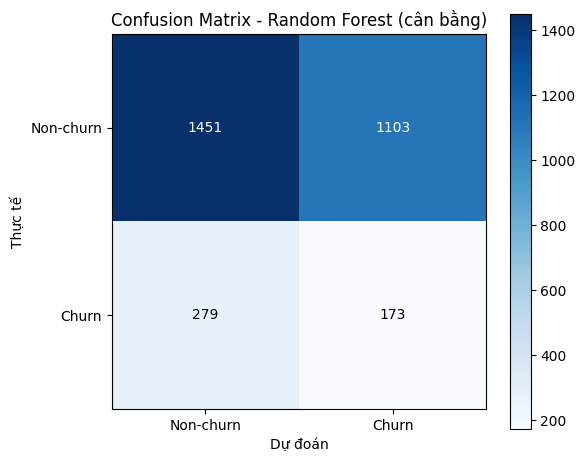

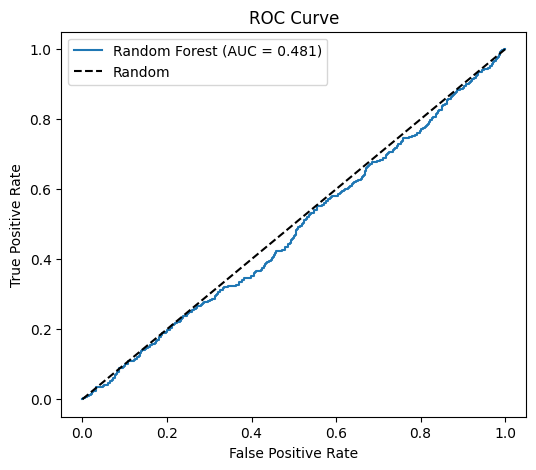

In [0]:
# Lấy predictions và labels về Pandas (vì dữ liệu không quá lớn)
predictions = rf_pred_bal.select("label", "prediction", "probability").toPandas()

# Confusion matrix thủ công
from sklearn.metrics import confusion_matrix, roc_curve, auc

cm = confusion_matrix(predictions["label"], predictions["prediction"])
print("Confusion matrix (thực tế vs dự đoán):")
print(cm)

# Vẽ confusion matrix
plt.figure(figsize=(6,5))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Random Forest (cân bằng)")
plt.colorbar()
tick_marks = np.arange(2)
plt.xticks(tick_marks, ["Non-churn", "Churn"])
plt.yticks(tick_marks, ["Non-churn", "Churn"])
plt.ylabel("Thực tế")
plt.xlabel("Dự đoán")

# Thêm số lượng vào ô
thresh = cm.max() / 2
for i in range(2):
    for j in range(2):
        plt.text(j, i, format(cm[i, j], 'd'),
                 ha="center", va="center",
                 color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

# ROC curve (cần xác suất của lớp positive)
probs = predictions["probability"].apply(lambda x: x[1])  # xác suất lớp 1
fpr, tpr, _ = roc_curve(predictions["label"], probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"Random Forest (AUC = {roc_auc:.3f})")
plt.plot([0,1], [0,1], 'k--', label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

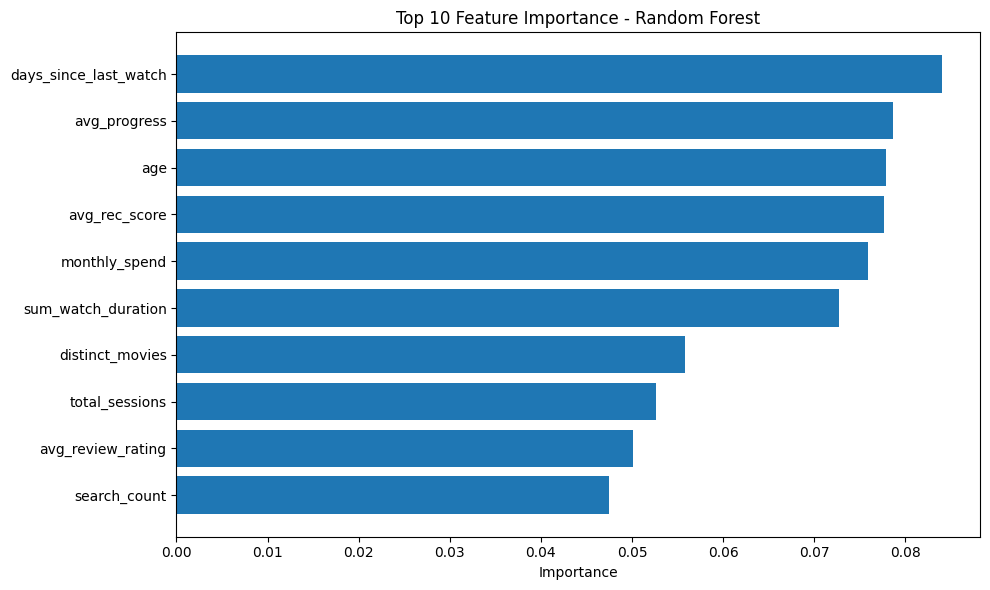


Chi tiết top 10 features:
days_since_last_watch: 0.0840
avg_progress: 0.0787
age: 0.0779
avg_rec_score: 0.0776
monthly_spend: 0.0760
sum_watch_duration: 0.0727
distinct_movies: 0.0558
total_sessions: 0.0526
avg_review_rating: 0.0501
search_count: 0.0475


In [0]:
# Lấy feature importance từ Random Forest model
importance = rf_model_bal.featureImportances
# Chuyển sang NumPy array để dễ xử lý
imp_array = importance.toArray()

# Top 10 features quan trọng nhất
feature_names = assembler_input  # danh sách tên feature (đã nối)
indices = np.argsort(imp_array)[::-1][:10]

plt.figure(figsize=(10,6))
plt.barh(range(10), imp_array[indices][::-1], align='center')
plt.yticks(range(10), [feature_names[i] for i in indices[::-1]])
plt.xlabel("Importance")
plt.title("Top 10 Feature Importance - Random Forest")
plt.tight_layout()
plt.show()

print("\nChi tiết top 10 features:")
for i in indices[:10]:
    print(f"{feature_names[i]}: {imp_array[i]:.4f}")

# 📌 Kết luận Gold Layer – Churn Prediction

## Kết quả đạt được
- Đã xây dựng pipeline hoàn chỉnh từ Bronze → Silver → Gold.
- Thực hiện feature engineering, xử lý mất cân bằng lớp (undersampling), huấn luyện 2 mô hình: **Logistic Regression** và **Random Forest**.
- Đã lưu mô hình vào MLflow cùng các tham số và chỉ số đánh giá.

## Hiệu suất mô hình
| Mô hình | AUC   | Accuracy |
|---------|-------|----------|
| Logistic Regression (cân bằng) | 0.4960 | 0.5615 |
| Random Forest (cân bằng)       | 0.4813 | 0.5403 |

**Nhận xét:**
- AUC xấp xỉ 0.5 → mô hình không phân biệt được churn và non‑churn tốt hơn ngẫu nhiên.
- Accuracy chỉ nhỉnh hơn 0.5 một chút.
- Feature importance cho thấy không có đặc trưng nào nổi trội (giá trị cao nhất chỉ ~0.08).

## Nguyên nhân
- Dữ liệu **synthetic** được tạo ngẫu nhiên, không có mối quan hệ thực sự giữa hành vi người dùng và việc rời bỏ.
- Các cột như `days_since_last_watch`, `avg_progress`, `age`… có tầm ảnh hưởng rất thấp.

## Đề xuất cho sản phẩm thực tế (production)
1. **Sử dụng dữ liệu thật** – đảm bảo có mối tương quan giữa hành vi và churn.
2. **Cân bằng lớp** – đã áp dụng, nhưng cần thử các phương pháp khác (SMOTE, class weight).
3. **Tinh chỉnh siêu tham số** (hyperparameter tuning) để cải thiện AUC.
4. **Tạo thêm features** mang tính xu hướng (ví dụ: % thay đổi thời gian xem theo tuần).
5. **Áp dụng threshold tối ưu** thay vì mặc định 0.5.

## Kết luận chung
Pipeline kỹ thuật (ingestion, cleaning, feature engineering, training, logging) **hoạt động ổn định và sẵn sàng** cho dữ liệu thật. Trong bối cảnh demo với dữ liệu synthetic, mô hình không có giá trị dự đoán, nhưng toàn bộ quy trình MLOps đã được minh họa đầy đủ.

## ⚖️ Xử lý mất cân bằng lớp (class imbalance)

Do tỷ lệ churn chỉ ~15%, mô hình thiên về dự đoán "không churn". Giải pháp: **Undersampling** – lấy ngẫu nhiên từ lớp đa số (non-churn) với số lượng bằng lớp thiểu số (churn). Sau đó gộp lại thành tập train cân bằng.